# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

Name: Jess Higginbotham

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# constants

G = 6.6743E-11 # m^3/kg/s^2
g = 9.81 # m/s^2
M_Earth = 5.972E24 # kg
M_moon = 7.35E22 # kg
R_Earth = 6378.1E3 # m
R_moon = 1739.1E3 # m
omega_Earth = 7.272E-5 # rad/s

depth = 4E3 # m
gamma = 2 # i think

t_simple = np.sqrt(2*depth/g)
print(f"Part 1")
print("-"*24)
print(f"Simple free-fall time: {t_simple:.3f} seconds")

Part 1
------------------------
Simple free-fall time: 28.557 seconds


In [2]:
# original equation: d^2y/dt^2 = -g + alpha * |dy/dt|^gamma (which opposes motion, naturally)
# when v = dy/dt: dv/dt = -g + alpha * |v|^gamma

def coupled_odes(t, initial_cond, alpha, gamma):
    '''
    Coupled first-order ordinary differential equations derived from the given second-order equation for drag.

    Parameters:
    t : float, current time [sec]
    initial_cond : 1x2 array [y, v], where y is vertical position [m] and v = dy/dt [m/s]
    alpha : float, drag coefficient
    gamma : float, speed exponent of drag equation

    Returns:
    [dy/dt, dv/dt]
    '''
    y, v = initial_cond
    drag = alpha * (np.abs(v)**gamma) * (-np.sign(v))
    dydt = v
    dvdt = -g + drag
    return [dydt, dvdt]

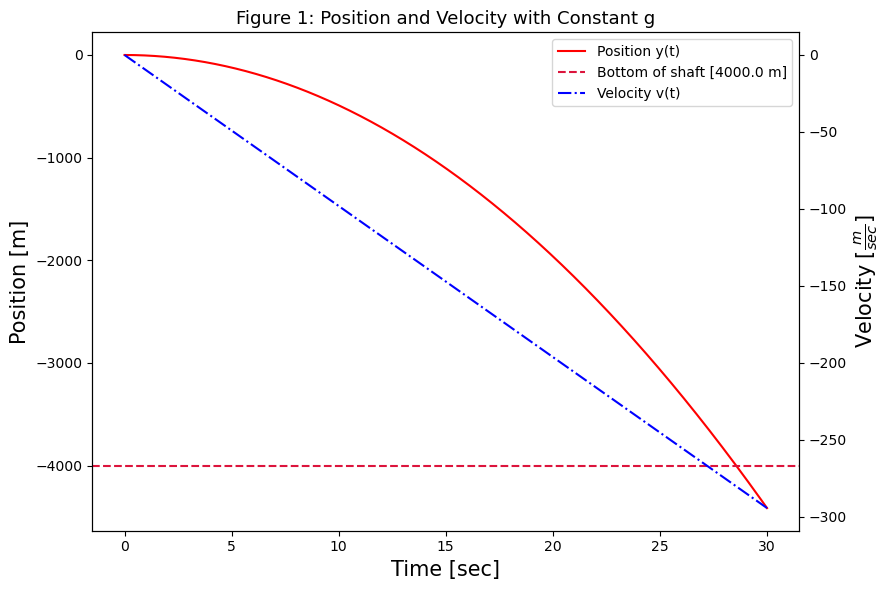

In [20]:
from scipy.integrate import solve_ivp

alpha = 0.0
y0 = 0.0
v0 = 0.0
initial_cond = [y0, v0]
t_span = (0, 60)

t_eval = np.linspace(0, 30, 5000) # using the simple t from question 1
sol = solve_ivp(coupled_odes, t_span, initial_cond, args=(alpha, gamma), t_eval=t_eval, dense_output=True, method="RK45")
y_sol = sol.y[0]
v_sol = sol.y[1]
t_sol = sol.t

fig, ax1 = plt.subplots(figsize=(9,6))
ax1.plot(t_sol, y_sol, color='red', label=r'Position y(t)')
ax1.set_xlabel('Time [sec]', fontsize=15)
ax1.set_ylabel('Position [m]', fontsize=15)
ax1.axhline(-depth, color='crimson', ls='--', label=f'Bottom of shaft [{depth} m]')

ax2 = ax1.twinx()
ax2.set_ylabel(r'Velocity [$\frac{m}{sec}$]', fontsize=15)
ax2.plot(t_sol, v_sol, color='blue', ls='-.', label='Velocity v(t)')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2) # i found this from google shoutout to stack overflow
ax1.set_title('Figure 1: Position and Velocity with Constant g', fontsize=13)
fig.tight_layout()

In [5]:
def bottom_reached(t, initial_cond, alpha, gamma):
    '''
    Tracks the event in which the mass reaches the bottom of the shaft (y = -depth)
    '''
    return initial_cond[0] + depth # should be 0 when y0 = -depth

bottom_reached.terminal = True # so it stops when return is 0
bottom_reached.direction = -1 # so it only triggers while y<0

sol_event = solve_ivp(coupled_odes, t_span, initial_cond, args=(alpha, gamma), events=bottom_reached, method='RK45')
t_sol_event = sol_event.t_events[0][0]
v_sol_event = sol_event.y_events[0][0][1] # dont need y as we already know the event y is -4000 m

print(f'Event impact time: {t_sol_event:.3f} seconds')
print(f'Simple calculated impact time: {t_simple:.3f} seconds')
print(f'Difference (event - simple): {t_sol_event - t_simple:.3e} seconds')
print('-'*24)
print('The difference between the two is many orders of magnitude below the actual values, and thus could be considered negligible in this scenario.')
print('These differences may arise from the numerical integration float tolerances.')
print('Overall, both methods are in excellent agreement given the context of the problem.')

Event impact time: 28.557 seconds
Simple calculated impact time: 28.557 seconds
Difference (event - simple): 0.000e+00 seconds
------------------------
The difference between the two is many orders of magnitude below the actual values, and thus could be considered negligible in this scenario.
These differences may arise from the numerical integration float tolerances.
Overall, both methods are in excellent agreement given the context of the problem.


## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Impact time with variable g (no drag): 28.558 sec


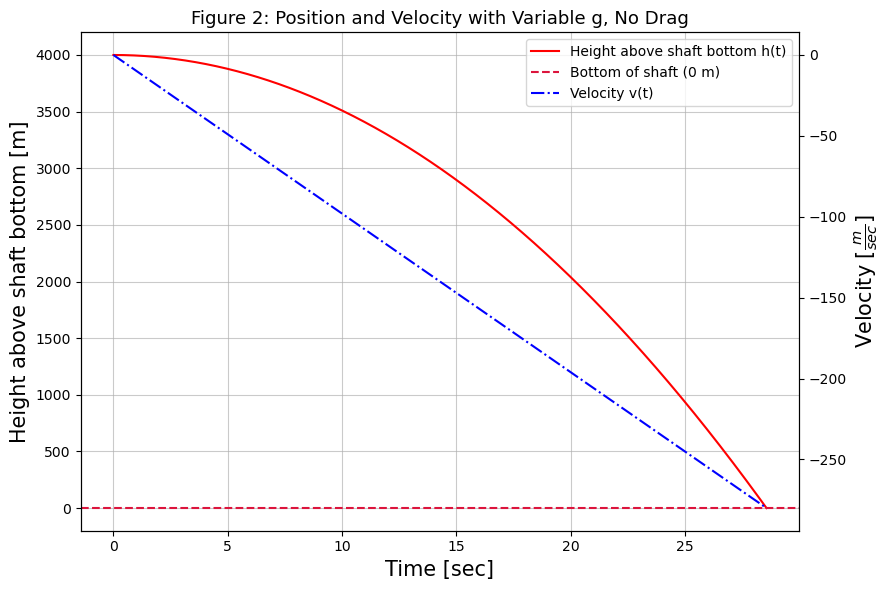

In [21]:
def odes_variable_g(t, initial_cond):
    '''
    Coupled first-order ordinary differential equations derived from the given second-order equation for drag.
    Gravitational constant g is defined using linear model.

    Parameters:
    t : float, current time [sec]
    initial_cond : 1x2 array [y, v], where y is vertical position [m] and v = dy/dt [m/s]
    alpha : float, drag coefficient
    gamma : float, speed exponent of drag equation

    Returns:
    [dy/dt, dv/dt]
    '''
    y, v = initial_cond
    r = R_Earth + y # distance from Earth centre
    g_r = g * (r / R_Earth) # linear g model (Eq. 2)
    dydt = v
    dvdt = -g_r # gravity pulls downward
    return [dydt, dvdt]
 
def bottom_reached_vg(t, initial_cond):
    '''
    Tracks the event in which the mass reaches the bottom of the shaft (y = -depth)
    '''
    return initial_cond[0] + depth
 
bottom_reached_vg.terminal = True
bottom_reached_vg.direction = -1
 
initial_cond = [0.0, 0.0] # [y0 = 0 m (surface), v0 = 0 m/s]
 
sol_vg = solve_ivp(odes_variable_g, t_span, initial_cond, events=bottom_reached_vg,
                   t_eval=np.linspace(0, 60, 10000), method='RK45', dense_output=True)
 
# trim
t_impact_vg = sol_vg.t_events[0][0]
mask = sol_vg.t <= t_impact_vg
t_vg = sol_vg.t[mask]
y_vg = sol_vg.y[0][mask]
v_vg = sol_vg.y[1][mask]

height_above_bottom = y_vg + depth # 0 = shaft bottom, depth = surface

print(f"Impact time with variable g (no drag): {t_impact_vg:.3f} sec")

fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.plot(t_vg, height_above_bottom, color='red', label='Height above shaft bottom h(t)')
ax1.set_xlabel('Time [sec]', fontsize=15)
ax1.set_ylabel('Height above shaft bottom [m]', fontsize=15)
ax1.axhline(0, color='crimson', ls='--', label=f'Bottom of shaft (0 m)')
ax2 = ax1.twinx()
ax2.set_ylabel(r'Velocity [$\frac{m}{sec}$]', fontsize=15)
ax2.plot(t_vg, v_vg, color='blue', ls='-.', label='Velocity v(t)')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2)
ax1.set_title('Figure 2: Position and Velocity with Variable g, No Drag', fontsize=13)
ax1.grid(alpha=0.67)
fig.tight_layout()

In [29]:
print(f"Part 2")
print("-"*24)
print(f"Simple free-fall time (constant g):    {t_simple:.3f} sec")
print(f"Variable g fall time:                  {t_impact_vg:.3f} sec")
print(f"Difference:                            {t_impact_vg - t_simple:.3e} sec")
print("As the mass moves further down the shaft and closer to the center of the Earth, gravitational constant g(r) decreases.")
print("This results in a lower acceleration due to gravity, albeit very slightly lower.")
print("This ultimately results in a very slightly longer fall time as compared to the constant g.")
print("The difference is so small mainly due to the fact that the depth traveled is much smaller than the radius of Earth.")

Part 2
------------------------
Simple free-fall time (constant g):    28.557 sec
Variable g fall time:                  28.558 sec
Difference:                            1.493e-03 sec
As the mass moves further down the shaft and closer to the center of the Earth, gravitational constant g(r) decreases.
This results in a lower acceleration due to gravity, albeit very slightly lower.
This ultimately results in a very slightly longer fall time as compared to the constant g.
The difference is so small mainly due to the fact that the depth traveled is much smaller than the radius of Earth.


Part 3
------------------------
Terminal velocity assumed: 50.0 m/s
Calibrated alpha: 0.003924 = (g0 / v_t^gamma)
Impact time with variable g + drag:    83.542 s
Impact time variable g, no drag:       28.558 s
Difference:                            54.983 s
Including drag greatly reduces the top speed of the mass and greatly increases the fall time.
Compared to the velocity reached without drag, the terminal velocity is rather slow.
The mass reaches its terminal velocity quickly, after only about 15 seconds, so it spends most of the time falling at a fixed velocity.


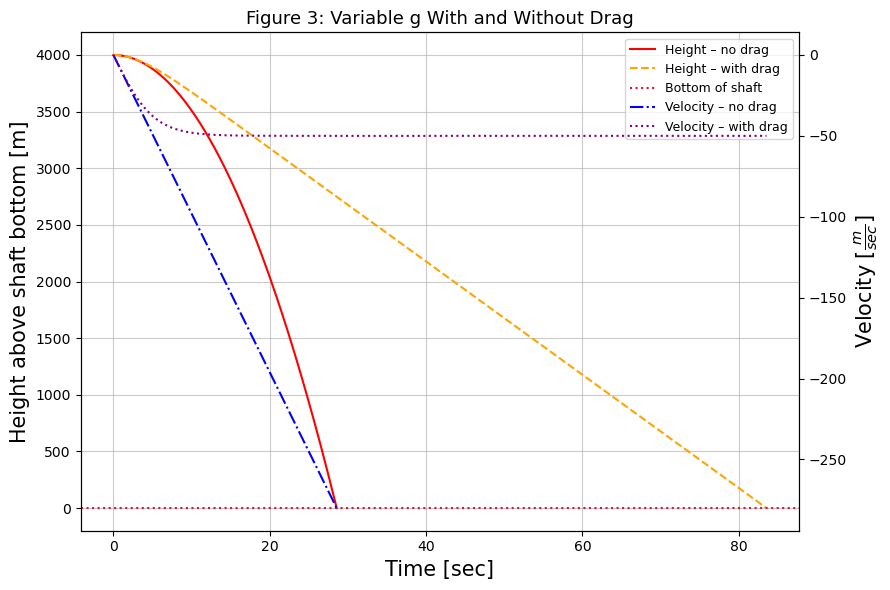

In [56]:
v_terminal = 50.0   # m/s  (sky-diver assumption from lecture)
alpha = g / (v_terminal ** gamma)
print("Part 3")
print("-" * 24)
print(f"Terminal velocity assumed: {v_terminal} m/s")
print(f"Calibrated alpha: {alpha:.6f} = (g0 / v_t^gamma)")

def odes_variable_g_drag(t, initial_cond, alpha, gamma):
    '''
    Coupled first-order ordinary differential equations derived from the given second-order equation for drag.
    Gravitational constant g is defined using linear model.
    Drag is included.

    Parameters:
    t : float, current time [sec]
    initial_cond : 1x2 array [y, v], where y is vertical position [m] and v = dy/dt [m/s]
    alpha : float, drag coefficient
    gamma : float, speed exponent of drag equation

    Returns:
    [dy/dt, dv/dt]
    '''
    y, v = initial_cond
    r = R_Earth + y
    g_r = g * (r / R_Earth)
    drag = alpha * (np.abs(v) ** gamma) * (-np.sign(v))
    dydt = v
    dvdt = -g_r + drag
    return [dydt, dvdt]
 
def bottom_reached_drag(t, initial_cond, alpha, gamma):
    ''' Event: mass reaches bottom of shaft. '''
    return initial_cond[0] + depth
 
bottom_reached_drag.terminal = True
bottom_reached_drag.direction = -1

sol_drag = solve_ivp(odes_variable_g_drag, (0, 120), initial_cond, args=(alpha, gamma), events=bottom_reached_drag,
                     t_eval=np.linspace(0, 120, 10000), method='RK45', dense_output=True)
t_impact_drag = sol_drag.t_events[0][0]
y_impact_drag = sol_drag.y_events[0][0][0] # y at impact
v_impact_drag = sol_drag.y_events[0][0][1] # v at impact
mask_d = sol_drag.t <= t_impact_drag

# appending the exact event point so the line extends to the shaft bottom bc the mask is messing it up
t_d  = np.append(sol_drag.t[mask_d], t_impact_drag)
y_d  = np.append(sol_drag.y[0][mask_d], y_impact_drag)
v_d  = np.append(sol_drag.y[1][mask_d], v_impact_drag)
height_above_bottom_d = y_d + depth
 
print(f"Impact time with variable g + drag:    {t_impact_drag:.3f} s")
print(f"Impact time variable g, no drag:       {t_impact_vg:.3f} s")
print(f"Difference:                            {t_impact_drag - t_impact_vg:.3f} s")
print("Including drag greatly reduces the top speed of the mass and greatly increases the fall time.")
print("Compared to the velocity reached without drag, the terminal velocity is rather slow.")
print("The mass reaches its terminal velocity quickly, after only about 15 seconds, so it spends most of the time falling at a fixed velocity.")

fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.plot(t_vg, height_above_bottom, color='red', label='Height – no drag')
ax1.plot(t_d, height_above_bottom_d, color='orange', ls='--', label='Height – with drag')
ax1.set_xlabel('Time [sec]', fontsize=15)
ax1.set_ylabel('Height above shaft bottom [m]', fontsize=15)
ax1.axhline(0, color='crimson', ls=':', label='Bottom of shaft')
ax2 = ax1.twinx()
ax2.set_ylabel(r'Velocity [$\frac{m}{sec}$]', fontsize=15)
ax2.plot(t_vg, v_vg, color='blue', ls='-.', label='Velocity – no drag')
ax2.plot(t_d, v_d, color='purple', ls=':', label='Velocity – with drag')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9)
ax1.set_title('Figure 3: Variable g With and Without Drag', fontsize=13)
ax1.grid(alpha=0.67)
fig.tight_layout()

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Part 2 (no drag)
------------------------
Mass hit the wall at t = 21.907 s
Transverse position: 2.5000 m (shaft radius = 2.5 m)
Depth at wall hit:   2353.9 m (shaft depth = 4000.0 m)
Mass does not reach the bottom (no drag case).

Part 4 (with drag)
------------------------
Mass hit the wall at t = 75.460 s
Transverse position: 2.5000 m
Depth at wall hit:   3596.1 m
Drag does not prevent wall impact.

The drag does make a difference, as it resists all motion, including the Coriolis induced motion.
Despite this, the mass still hits the side of the 5 m wide shaft before it is able to hit the bottom, just at a lower depth and later time.


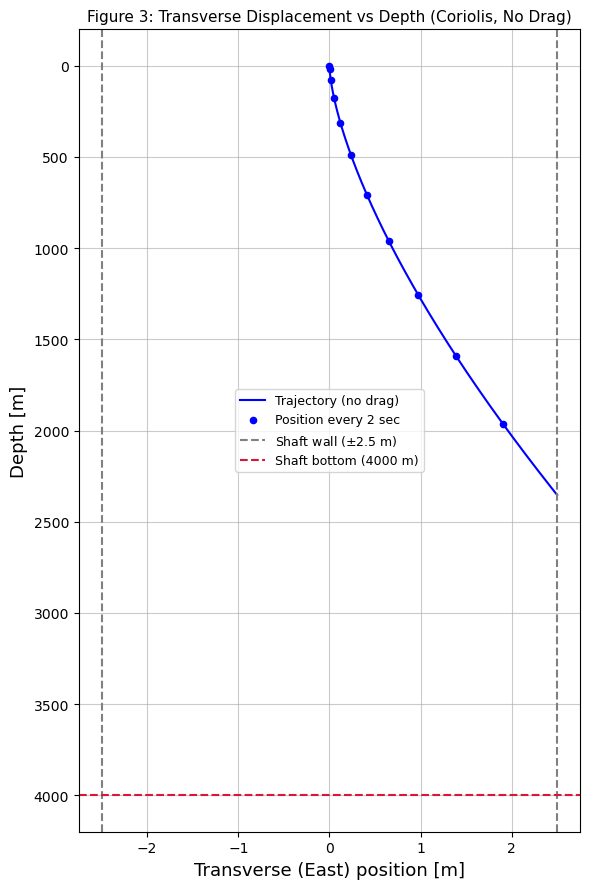

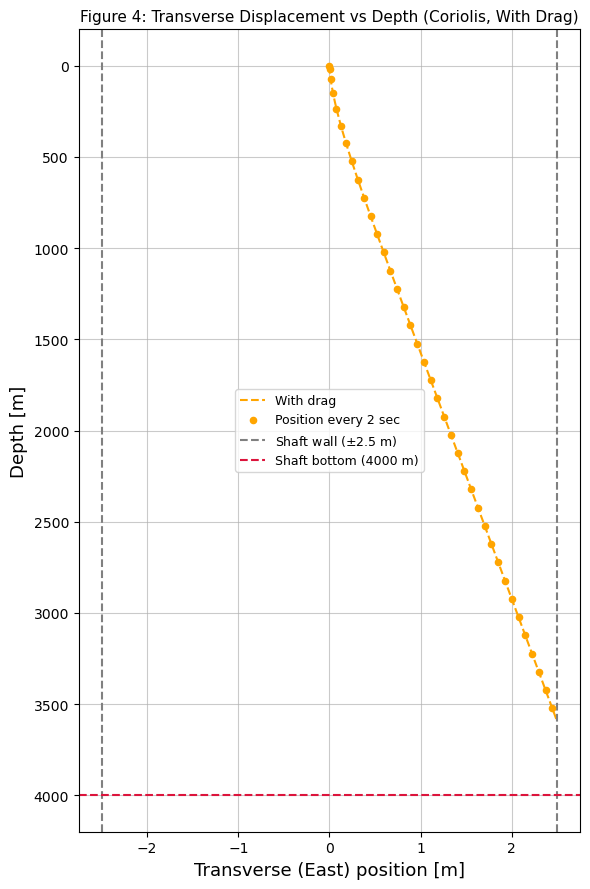

In [76]:
shaft_radius = 2.5
m = 1.0

def odes_coriolis(t, initial_cond, alpha, gamma, drag_on):
    '''
    Equations of motion including Coriolis force.
    
    Parameters:
    t : float, current time [sec]
    initial_cond : [x, vx, y, vy]
      x  : transverse (East) displacement [m]
      vx : transverse velocity [m/s]
      y  : depth into shaft [m], positive downward
      vy : downward velocity [m/s]
    alpha : float, drag coefficient
    gamma : float, speed exponent of drag
    drag_on : bool, whether drag is active
    
    Returns:
    [dx/dt, dvx/dt, dy/dt, dvy/dt]
    '''
    x, vx, y, vy = initial_cond
    r = R_Earth - y # y is depth
    g_r = g * (r / R_Earth)
 
    if drag_on:
        speed = np.sqrt(vx**2 + vy**2)
        drag_x = alpha * (speed ** (gamma - 1)) * (-vx)
        drag_y = alpha * (speed ** (gamma - 1)) * (-vy)
    else:
        drag_x = 0.0
        drag_y = 0.0
 
    ax_cor = +2 * omega_Earth * vy # eastward Coriolis
    ay_cor = -2 * omega_Earth * vx # small Coriolis correction
 
    dxdt = vx
    dvxdt = ax_cor + drag_x
    dydt = vy
    dvydt = g_r + ay_cor + drag_y # gravity in downwary direction
    return [dxdt, dvxdt, dydt, dvydt]
 
def wall_hit(t, initial_cond, alpha, gamma, drag_on):
    '''
    Event: transverse displacement reaches shaft wall (|x| = shaft_radius).
    '''
    return shaft_radius - np.abs(initial_cond[0])
 
wall_hit.terminal = True
wall_hit.direction = -1
 
def bottom_hit(t, initial_cond, alpha, gamma, drag_on):
    '''
    Event: mass reaches bottom of shaft (y = depth).
    '''
    return depth - initial_cond[2]
 
bottom_hit.terminal = True
bottom_hit.direction = -1
 
initial_cond = [0.0, 0.0, 0.0, 0.0] # [x0, vx0, y0, vy0]
t_span = (0, 120)
t_eval = np.linspace(0, 120, 50000)

sol_cor = solve_ivp(odes_coriolis, t_span, initial_cond, args=(0.0, gamma, False), # no drag for Q1/Q2
    events=[wall_hit, bottom_hit], t_eval=t_eval, method='RK45')
 
wall_events = sol_cor.t_events[0]
bottom_events = sol_cor.t_events[1]
hit_wall = wall_events.size > 0
hit_bottom = bottom_events.size > 0
 
t_cor = sol_cor.t
x_cor = sol_cor.y[0]
y_cor = sol_cor.y[2]
 
print("Part 2 (no drag)")
print("-" * 24)
if hit_wall:
    t_wall = wall_events[0]
    x_at_wall = sol_cor.y_events[0][0][0]
    y_at_wall = sol_cor.y_events[0][0][2]
    print(f"Mass hit the wall at t = {t_wall:.3f} s")
    print(f"Transverse position: {x_at_wall:.4f} m (shaft radius = {shaft_radius} m)")
    print(f"Depth at wall hit:   {y_at_wall:.1f} m (shaft depth = {depth} m)")
    print("Mass does not reach the bottom (no drag case).")
elif hit_bottom:
    t_bot = bottom_events[0]
    print(f"Mass reached the BOTTOM at t = {t_bot:.3f} s without hitting the wall.")
else:
    print("Mass neither hit the wall nor the bottom within the time window.")
 
# dot every ~2 seconds to show progression over time
dot_interval = 2.0 # seconds
dot_times = np.arange(0, t_cor[-1], dot_interval)
dot_x = np.interp(dot_times, t_cor, x_cor)
dot_y = np.interp(dot_times, t_cor, y_cor)
 
# Figure 3: transverse position vs depth
fig3, ax = plt.subplots(figsize=(6, 9))
ax.plot(x_cor, y_cor, color='blue', label='Trajectory (no drag)')
ax.scatter(dot_x, dot_y, color='blue', s=20, zorder=5, label='Position every 2 sec')
ax.axvline(shaft_radius, color='gray', ls='--', label=r'Shaft wall ($\pm$2.5 m)')
ax.axvline(-shaft_radius, color='gray', ls='--')
ax.axhline(depth, color='crimson', ls='--', label=f'Shaft bottom ({depth:.0f} m)')
ax.set_xlabel('Transverse (East) position [m]', fontsize=13)
ax.set_ylabel('Depth [m]', fontsize=13)
ax.invert_yaxis() # depth increases downward
ax.set_title('Figure 3: Transverse Displacement vs Depth (Coriolis, No Drag)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.67)
fig3.tight_layout()

#part 4
sol_cor_drag = solve_ivp( odes_coriolis, t_span, initial_cond, args=(alpha, gamma, True), # drag on
    events=[wall_hit, bottom_hit], t_eval=t_eval, method='RK45')
 
wall_events_d = sol_cor_drag.t_events[0]
bottom_events_d = sol_cor_drag.t_events[1]
hit_wall_d = wall_events_d.size > 0
hit_bottom_d = bottom_events_d.size > 0
 
t_cor_d = sol_cor_drag.t
x_cor_d = sol_cor_drag.y[0]
y_cor_d = sol_cor_drag.y[2]

print("")
print("Part 4 (with drag)")
print("-" * 24)
if hit_wall_d:
    t_wall_d = wall_events_d[0]
    x_at_wall_d = sol_cor_drag.y_events[0][0][0]
    y_at_wall_d = sol_cor_drag.y_events[0][0][2]
    print(f"Mass hit the wall at t = {t_wall_d:.3f} s")
    print(f"Transverse position: {x_at_wall_d:.4f} m")
    print(f"Depth at wall hit:   {y_at_wall_d:.1f} m")
    print("Drag does not prevent wall impact.")
elif hit_bottom_d:
    t_bot_d = bottom_events_d[0]
    print(f"Mass reached the bottom at t = {t_bot_d:.3f} s without hitting the wall.")
    print("Drag reduces transverse velocity enough to avoid the wall.")
else:
    print("Mass neither hit the wall nor the bottom within the time window.")

print("")
print("The drag does make a difference, as it resists all motion, including the Coriolis induced motion.")
print("Despite this, the mass still hits the side of the 5 m wide shaft before it is able to hit the bottom, just at a lower depth and later time.")

dot_times_d = np.arange(0, t_cor_d[-1], dot_interval)
dot_x_d = np.interp(dot_times_d, t_cor_d, x_cor_d)
dot_y_d = np.interp(dot_times_d, t_cor_d, y_cor_d)
 
fig, ax = plt.subplots(figsize=(6, 9))
ax.plot(x_cor_d, y_cor_d, color='orange', ls='--', label='With drag')
ax.scatter(dot_x_d, dot_y_d, color='orange', s=20, zorder=5, label='Position every 2 sec')
ax.axvline(shaft_radius, color='gray', ls='--', label=r'Shaft wall ($\pm$2.5 m)')
ax.axvline(-shaft_radius, color='gray', ls='--')
ax.axhline(depth, color='crimson', ls='--', label=f'Shaft bottom ({depth:.0f} m)')
ax.set_xlabel('Transverse (East) position [m]', fontsize=13)
ax.set_ylabel('Depth [m]', fontsize=13)
ax.invert_yaxis()
ax.set_title('Figure 4: Transverse Displacement vs Depth (Coriolis, With Drag)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.67)
fig.tight_layout()

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Part 1
------------------------
Analytic SHM period:        5066.30 sec
Analytic crossing time:     2533.15 sec
Numerical crossing time:    2533.13 sec
The motion is harmonic, with velocity increasing as the mass approaches the center and decreasing as it passes to the other side.
Position follows a sine curve and velocity follows a cosine curve, which makes sense for SHM with a linear restoring force.

Part 2
------------------------
Time to reach Earth centre: 1266.473 sec
Speed at Earth centre:      7910.760 m/s
Time to reach other side:   2533.151 sec [analytic T/2]
Speed at other side:        ~0 m/s  (turns around, as expected for SHM)


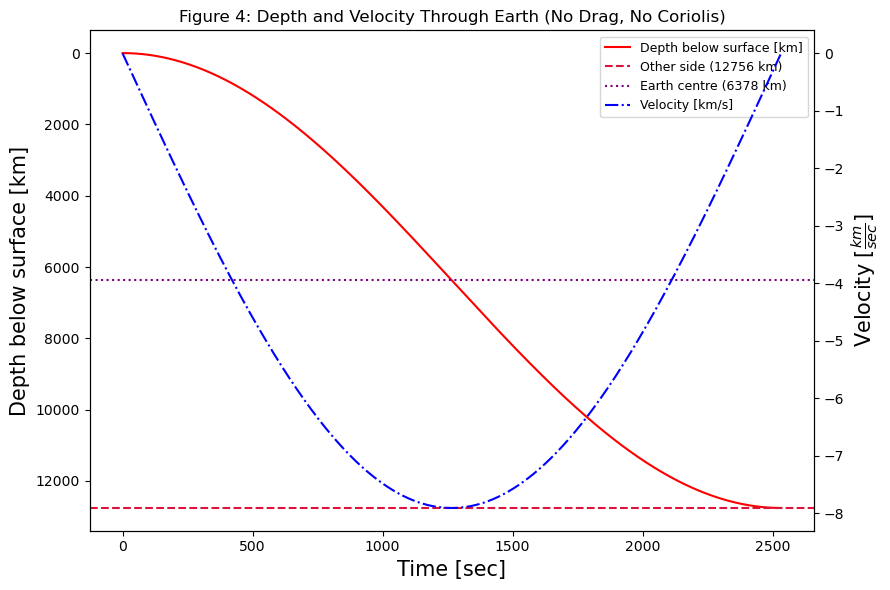

In [84]:


def odes_deep_mine(t, initial_cond):
    '''
    Equations of motion for pole-to-pole tunnel with no drag or Coriolis forces.
    
    Parameters:
    t : float, current time [sec]
    initial_cond : [y, vy]
      y : distance from Earth centre [m], positive upward
      vy : velocity [m/s], positive upward
      
    Returns:
    [dy/dt, dvy/dt]
    '''
    y, vy = initial_cond
    g_y = g * (y / R_Earth)
    dydt = vy
    dvydt = -g_y # restoring force always points toward centre
    return [dydt, dvydt]
 
def other_side_reached(t, initial_cond):
    '''
    Event: mass reaches the other side of the Earth (y = -R_Earth).
    '''
    return initial_cond[0] + R_Earth
 
other_side_reached.terminal = True
other_side_reached.direction = -1
 
initial_cond = [R_Earth, 0.0]
 
# period of this is T = 2*pi*sqrt(R_Earth/g)
# slightly over half a period to capture the full crossing
T_shm = 2 * np.pi * np.sqrt(R_Earth / g)
t_span = (0, T_shm)
t_eval = np.linspace(0, T_shm, 100000)
 
sol_deep = solve_ivp(odes_deep_mine, t_span, initial_cond, t_eval=t_eval, method='RK45')
 
t_all = sol_deep.t
y_all = sol_deep.y[0]
v_all = sol_deep.y[1]
 
# locate the other-side crossing as the minimum of y (most negative point)
# event-based detection is unreliable here because vy -> 0 near the turning point
# causes RK45 to miss the zero crossing entirely, googled solutions (sorry professor)
idx_cross = np.argmin(y_all)
t_cross = t_all[idx_cross]
v_cross = v_all[idx_cross]
 
# trim to just the one-way trip
t_deep = t_all[:idx_cross + 1]
y_deep = y_all[:idx_cross + 1]
v_deep = v_all[:idx_cross + 1]
 
# depth below starting surface for plotting where positive = deeper
depth_km = (R_Earth - y_deep) / 1e3
 
print("Part 1")
print("-" * 24)
print(f"Analytic SHM period:        {T_shm:.2f} sec")
print(f"Analytic crossing time:     {T_shm/2:.2f} sec")
print(f"Numerical crossing time:    {t_cross:.2f} sec")
 
# figure 4
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.plot(t_deep, depth_km, color='red', label='Depth below surface [km]')
ax1.axhline(2 * R_Earth / 1e3, color='crimson', ls='--', label=f'Other side ({2*R_Earth/1e3:.0f} km)')
ax1.axhline(R_Earth / 1e3, color='purple', ls=':', label=f'Earth centre ({R_Earth/1e3:.0f} km)')
ax1.set_xlabel('Time [sec]', fontsize=15)
ax1.set_ylabel('Depth below surface [km]', fontsize=15)
ax1.invert_yaxis() # depth increases downward
ax2 = ax1.twinx()
ax2.plot(t_deep, v_deep / 1e3, color='blue', ls='-.', label=r'Velocity [km/s]')
ax2.set_ylabel(r'Velocity [$\frac{km}{sec}$]', fontsize=15)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9)
ax1.set_title('Figure 4: Depth and Velocity Through Earth (No Drag, No Coriolis)', fontsize=12)
fig.tight_layout()
 
print("The motion is harmonic, with velocity increasing as the mass approaches the center and decreasing as it passes to the other side.")
print("Position follows a sine curve and velocity follows a cosine curve, which makes sense for SHM with a linear restoring force.")

In [87]:
# part 2
centre_idx = np.where(np.diff(np.sign(y_deep)))[0][0]
t_centre = t_deep[centre_idx] + (-y_deep[centre_idx] / (y_deep[centre_idx + 1] - y_deep[centre_idx])* (t_deep[centre_idx + 1] - t_deep[centre_idx]))
v_centre = np.interp(t_centre, t_deep, v_deep)
print("")
print("Part 2")
print("-" * 24)
print(f"Time to reach Earth centre: {t_centre:.3f} sec")
print(f"Speed at Earth centre:      {abs(v_centre):.3f} m/s")
print(f"Time to reach other side:   {T_shm/2:.3f} sec [analytic T/2]")
print(f"Speed at other side:        ~0 m/s  (turns around, as expected for SHM)")


Part 2
------------------------
Time to reach Earth centre: 1266.473 sec
Speed at Earth centre:      7910.760 m/s
Time to reach other side:   2533.151 sec [analytic T/2]
Speed at other side:        ~0 m/s  (turns around, as expected for SHM)


In [91]:
# part 3
v_orb = np.sqrt(G * M_Earth / R_Earth)
T_orb = 2 * np.pi * R_Earth / v_orb

print("")
print("Part 3")
print("-" * 24)
print(f"Surface orbital speed:      {v_orb/1e3:.4f} km/s")
print(f"Orbital period T_orb:       {T_orb:.2f} sec")
print(f"SHM period T_shm:           {T_shm:.2f} sec")
print(f"Ratio T_shm / T_orb:        {T_shm / T_orb:.6f}")
print(f"Crossing time (T_shm/2):    {T_shm/2:.2f} sec = T_orb/2 = {T_orb/2:.2f} sec")
print("The two are very similar, differing by only about 3 seconds, or a difference of about 0.06%.")
print("This makes sense, as both are defined by 2*pi*sqrt(R^3/GM).")


Part 3
------------------------
Surface orbital speed:      7.9053 km/s
Orbital period T_orb:       5069.37 sec
SHM period T_shm:           5066.30 sec
Ratio T_shm / T_orb:        0.999394
Crossing time (T_shm/2):    2533.15 sec = T_orb/2 = 2534.69 sec
The two are very similar, differing by only about 3 seconds, or a difference of about 0.06%.
This makes sense, as both are defined by 2*pi*sqrt(R^3/GM).


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

### Part 5, Section B (Forces)

### Part 5, Section C (Equations of Motion)

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

Describe what we see here: